# Package Groupe 19

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors

import package_DBR
from package_DBR import myRound, SelectPath_RT, Delay_RT, FO_RT, FOPDT, SOPDT, FOPDT_cost, SOPDT_cost, Process, Bode
from package_Lab import LL_RT

# LEAD_LAG_RT()

In [5]:
help(LL_RT)

Help on function LL_RT in module package_Lab:

LL_RT(MV, Kp, Ts, T_LEAD, T_LAG, PV, PVInit=0)
    The function "LL_RT" needs to be included in a "for or while loop".

    :MV: input vector
    :Kp: process gain
    :T_LEAD: lead time constant [s]
    :T_LAG: lag time constant [s]
    :Ts: sampling period [s]
    :PV: output vector
    :PVInit: (optional: default value is 0)

    The function "LL_RT" appends a value to the output vector "PV".
    The appended value is obtained from a recurrent equation that depends on the discretisation method.



(0.0, 100.0)

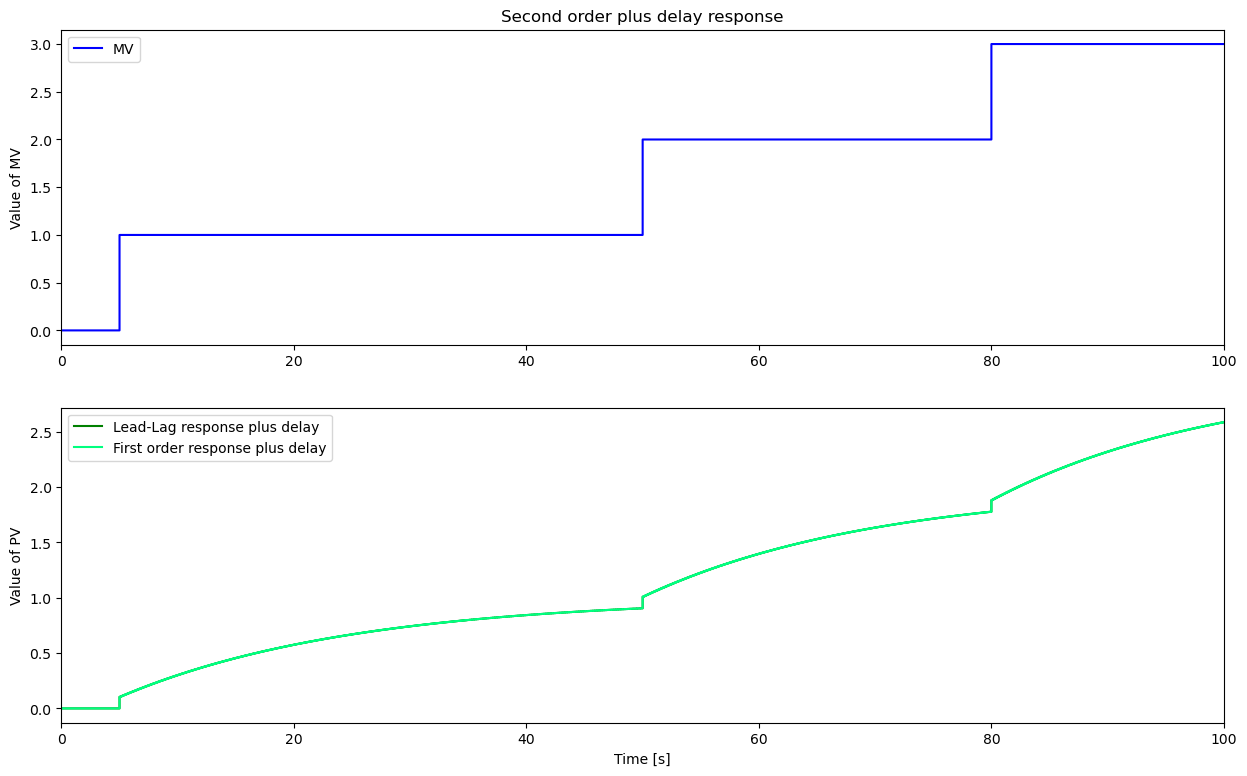

In [6]:
TSim = 100
Ts = 0.1
N = int(TSim/Ts) + 1

# Path for MV
MVPath = {0: 0, 5: 1, 50: 2, 80: 3, TSim: 3}

t = []
MV = []
PV = []

# Parameters
kp = 1
T_Lead = 2
T_Lag = 20


# MV is created from MVPath
for i in range(0,N):
    t.append(i*Ts)
    SelectPath_RT(MVPath,t,MV)
    LL_RT(MV,kp,Ts,T_Lead,T_Lag,PV,PVInit=0)
    

    
plt.figure(figsize = (15,9))

plt.subplot(2,1,1)
plt.step(t,MV,'b-',label='MV',where='post')
plt.ylabel('Value of MV')
plt.title('Second order plus delay response')
plt.legend(loc='best')
plt.xlim([0, TSim])

plt.subplot(2,1,2)
plt.step(t,PV,'g-',label='Lead-Lag response plus delay',where='post')
plt.step(t,PV,'springgreen',label='First order response plus delay',where='post')
plt.ylabel('Value of PV')
plt.xlabel('Time [s]')
plt.legend(loc='best')
plt.xlim([0, TSim])